# Resolução da segunda avaliação da disciplina de Fundamentos Computacionais para Engenharia.

## PARTE 1 – Conceitos Fundamentais (teoria e compreensão)

### Questão 1:

A Programação Orientada a Equações (POE) é um paradigma que permite ao programador descrever um problema com foco em sua estrutura lógica, aproximando a modelagem computacional das equações matemáticas do processo físico.

(a) Explique como a POE difere da programação imperativa, considerando o papel do programador e o processo de obtenção da solução.

(b) Em que tipo de problema de engenharia a POE é mais vantajosa? Cite pelo menos um exemplo prático — diferente dos discutidos em sala.

(c) Um dos princípios mais valorizados da POE é a flexibilidade. O que esse princípio significa na prática? Por que ele é útil para o engenheiro químico?

**(a)** A Programação Orientada a Equações (POE) difere da programação imperativa principalmente na forma como o problema é estruturado no código. Quando utilizada a POE, existe um paradigma de programação onde o foco está na definição das equações que representam o comportamento físico do problema, dessa forma, o solucionador resolve o modelo. Já na programação imperativa, o código é formado tipo uma receita, sendo resolvido passo a passo para chegar à solução do problema.

Quando pensamos no papel do programador, trabalhando com a programação imperativa ele deve definir detalhadamente a sequência de comandos, até a solução do problema. Já trabalhando com a POE o programador descreve as relações matemáticas entre as variáveis, resultando em um código mais conciso e modular, o que facilita a leitura e a manutenção do modelo.

**(b)** A POE é vantajosa em problemas que demandam alta complexidade computacional e envolvem a modelagem de diferentes fenômenos físicos interligados. Segundo Mattsson et al. (1998), a linguagem Modelica, baseada em POE, permite a modelagem de sistemas físicos complexos utilizando equações gerais, sem que o programador precise escolher manualmente quais variáveis resolver, podendo ser utilizado para modelagem de mecatrônica, incluindo carros, aeronaves e robôs industriais, que normalmente consistem em subsistemas mecânicos, elétricos e hidráulicos, bem como sistemas de controle.


> MATTSSON, Sven Erik; ELMQVIST, Hilding; OTTER, Martin. Physical system modeling with Modelica. Mathematical and Computer Modelling of Dynamical Systems, v. 4, n. 1, p. 23–50, 1998.



**(c)** A flexibilidade na POE significa que o mesmo conjunto de equações pode ser utilizado para resolver diferentes variáveis, dependendo do objetivo da simulação. Acredito que para o engenheiro químico, essa característica é bastante útil, principalmente pelo fato de poder analisar diferentes cenários ao mesmo tempo, variando as condições de contorno, parâmetros operacionais ou até mesmo as variáveis do projeto, sem a necessidade de reescrever o modelo.



---



### Questão 2:

Ao desenvolver soluções computacionais, a organização do código é essencial para sua manutenção, reusabilidade e adaptação a novos cenários.

(a) Explique o papel da estrutura @dataclass em Python na organização dos códigos. Por que ela é especialmente útil em sistemas com muitos parâmetros de entrada?

(b) Por que se recomenda salvar as soluções em repositórios como o GitHub? Cite três benefícios práticos, relacionando-os com a prática profissional ou acadêmica.

**(a)** A estrutura @dataclass, pertencente ao módulo dataclasses, é uma forma automática de criar classes com atributos, focada em organizar dados de maneira limpa. É importante pois organiza todos os parâmetros de entrada, com isso evita principalmente erro na hora de atribuir valores para as variáveis. Cada variável com sua respectiva classe, além disso, @dataclass facilita o reuso e a motificação dos dados, deixando o código legível e modular.


**(b)** É recomendado utilizar o reposítório do GitHub por vários motivos. Acredito que o principal motivo para upar um código em um repositório é disceminar conhecimento, a plataforma permite compartilhar códigos com a comunidade, acessar projetos consolidados e encontrar soluções inovadoras.

Um outro motivo importante para a indexação nos repositórios do GitHub é o armazenamento em nuvem, que facilita o acesso, o backup e a portabilidade do código.

Por último e mais interssante é a forma de integração GitHub x Google Colab, permitindo importar funções diretamente do repositório, reutilizar trechos de código e consultar documentações com facilidade, tornando muito mais dinâmico e produtivo, além da opção do usuário não visualizar a definição da função mas poder utiliza-la para resolver seus problemas.



---



## Parte 2 - Aplicações e lógica computacional

### Questão 3:

Fermentação alcoólica com cinética dependente da temperatura - Um processo em
batelada converte glicose em etanol e CO2. A taxa de consumo da glicose depende da temperatura segundo a expressão:

$$k(T) = 464.8 \cdot \exp\left(\frac{-3985}{T\ (^\circ\mathrm{C}) + 273}\right) \quad [\mathrm{L/min}]$$

A cinética é de primeira ordem, tal que:

$$\frac{dS}{dt} = -k(T) \cdot S$$

Considerando concentração inicial S(t = 0) de glicose igual a 100 g/L e temperatura constante de 35°C, implemente uma solução computacional para simular a concentração de glicose ao longo de 24 horas. Qual o valor final da concentração de glicose? O que acontece se a temperatura for aumentada para 50°C?

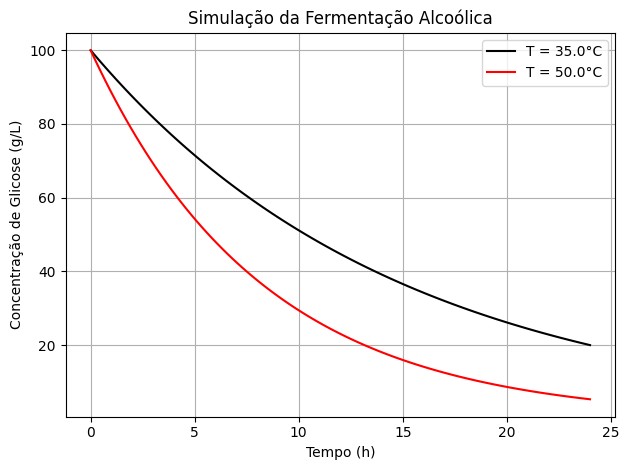

Concentração final de glicose a 35.0°C: 20.01 g/L
Concentração final de glicose a 50.0°C: 5.31 g/L


In [22]:
# 1. Importações
import numpy as np
from scipy.integrate import solve_ivp
from dataclasses import dataclass
import matplotlib.pyplot as plt

# 2. Classe de parâmetros
@dataclass
class ParametrosFermentacao:
    """Parâmetros do modelo de fermentação alcoólica."""
    S0: float = 100.0  # concentração inicial de glicose (g/L)
    T: float = 35.0    # temperatura do processo (°C)

# 3. Função do modelo (EDO)
def modelofermentacao(t, S, params):
    """
    Modelo cinético de primeira ordem para a fermentação alcoólica.

    Argumentos:
        t (float): tempo (min)
        S (float): concentração de glicose (g/L)
        params (ParametrosFermentacao): parâmetros do processo

    Returns:
        dS/dt (float): taxa de variação da concentração
    """
    T = params.T
    k = 464.8 * np.exp(-3985 / (T + 273))  # L/min
    dSdt = -k * S
    return dSdt

# 4. Função de simulação
def simularfermentacao(tempo_min, parametros):
    """
    Executa a simulação numérica da fermentação.

    Argumentos:
        tempo_min (list): intervalo de tempo [min]
        parametros (ParametrosFermentacao): parâmetros do modelo

    Returns:
        t (array): vetor de tempo
        S (array): vetor de concentrações
        S_final (float): concentração final
    """
    t_eval = np.linspace(tempo_min[0], tempo_min[-1], 100)
    sol = solve_ivp(modelofermentacao, tempo_min, [parametros.S0], t_eval=t_eval, args=(parametros,), method='BDF')
    return sol.t, sol.y[0], sol.y[0, -1]

# 5. Execução da simulação para diferentes temperaturas
tempos = [0, 24*60]  # 24 horas em minutos
casos = [ParametrosFermentacao(T=35.0),
         ParametrosFermentacao(T=50.0)]

cores = ['black', 'red'] # Define as cores para cada caso (preto e vermelho)

resultados = []
for i, caso in enumerate(casos):
    t, S, S_final = simularfermentacao(tempos, caso)
    plt.plot(t/60, S, label=f"T = {caso.T}°C", color=cores[i]) # Usa a cor correspondente
    resultados.append((caso.T, S_final))

# 6. Gráfico
plt.xlabel('Tempo (h)')
plt.ylabel('Concentração de Glicose (g/L)')
plt.title('Simulação da Fermentação Alcoólica')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# 7. Resultados
for T, S_final in resultados:
    print(f"Concentração final de glicose a {T}°C: {S_final:.2f} g/L")



---



### Questão 4 — Equilíbrio em Coluna de Destilação com Seletividade Dependente da Temperatura

Um processo modelado com **três estágios** separa uma mistura etanol/água.  
A fração molar líquida de etanol \( x_i \) e a temperatura \( T_i \) em cada estágio são conhecidas.

O **equilíbrio líquido-vapor** é dado por:

$$
y_i = \frac{\alpha(T_i) \cdot x_i}{1 + [\alpha(T_i) - 1] \cdot x_i}
$$

A **seletividade** depende da temperatura e é definida pela expressão linear:

$$
\alpha(T) = 2.5 - 0.01 \cdot (T - 78)
$$

Os dados fornecidos para os três estágios são:

| Estágio      | \( x_i \) | \( T_i \) (°C) |
|--------------|-----------|----------------|
| 1 (topo)     | 0.20      | 78             |
| 2 (alimentação) | 0.40   | 80             |
| 3 (fundo)    | 0.60      | 85             |


Escreva um código modular que calcule e exiba a seletividade (alpha_i) em cada estágio e a fração (y_i) com base nos dados acima.
Escreva um código modular que:

In [23]:
# Importações
import numpy as np
from dataclasses import dataclass

# Criamos uma classe simples para guardar os dados de cada estágio
@dataclass
class EstagioColuna:
    x: float  # fração molar líquida de etanol
    T: float  # temperatura do estágio (°C)

# Função que calcula a seletividade e a fração de vapor
def calcular_equilibrio(estagio):
    """
    Calcula a seletividade e a fração molar de vapor em um estágio da coluna de destilação.

    Argumentos:
        estagio (EstagioColuna): Objeto contendo a fração molar líquida (x) e a temperatura (T) do estágio.

    Returns:
        alpha (float): A seletividade no estágio.
        y (float): A fração molar de vapor no estágio.
    """
    # Extrai os dados do estágio
    x = estagio.x
    T = estagio.T

    # Calcula a seletividade com base na temperatura
    alpha = 2.5 - 0.01 * (T - 78)

    # Aplica a fórmula do equilíbrio líquido-vapor
    y = (alpha * x) / (1 + (alpha - 1) * x)

    return alpha, y

# Definimos os três estágios com os dados fornecidos
estagios = [
    EstagioColuna(x=0.20, T=78),
    EstagioColuna(x=0.40, T=80),
    EstagioColuna(x=0.60, T=85)]

# Para cada estágio, calculamos e mostramos os resultados
for i, estagio in enumerate(estagios, start=1):
    alpha, y = calcular_equilibrio(estagio)
    print(f"Estágio {i}: α = {alpha:.2f}, y = {y:.2f}")

Estágio 1: α = 2.50, y = 0.38
Estágio 2: α = 2.48, y = 0.62
Estágio 3: α = 2.43, y = 0.78
